In [1]:
import pandas as pd

# Load CSV (Dataset)
repo_df = pd.read_csv('characteristics_repo.csv')
markdown_irt_df = pd.read_csv('characteristics_irts_markdown.csv')
yaml_irt_df = pd.read_csv('characteristics_irts_yaml.csv')

print(repo_df.head())
print(markdown_irt_df.head())
print(yaml_irt_df.head())


                          full_name  is_fork  has_issues           created_at  \
0        josch/cycles_johnson_meyer    False        True  2012-07-04 12:02:27   
1   hantsy/angularjs-cakephp-sample    False        True  2013-11-06 12:56:34   
2          metabase/metabase-deploy    False       False  2015-10-08 00:01:18   
3  sakshamsharma/http-over-protocol    False        True  2016-08-30 10:53:30   
4                  sradley/overflow    False        True  2020-10-27 06:30:05   

                   last_modified            pushed_at main_language  \
0  Sun, 01 Jan 2023 16:35:16 GMT  2018-07-05 03:54:37          Java   
1  Wed, 07 Dec 2022 18:29:56 GMT  2015-10-08 05:00:41           PHP   
2  Sat, 10 Dec 2022 12:07:00 GMT  2022-08-05 22:57:15         Shell   
3  Tue, 15 Nov 2022 20:41:40 GMT  2016-09-25 04:59:55           C++   
4  Thu, 01 Dec 2022 11:13:38 GMT  2022-12-18 03:42:19            Go   

   total_issues_count  open_issues_count  closed_issues_count  ...  \
0               

In [2]:
rows1, columns1 = repo_df.shape

# Print the number of rows and columns
print(f"The repo dataset has {rows1} rows and {columns1} columns.")

The repo dataset has 1084300 rows and 29 columns.


In [3]:
rows2, columns2 = markdown_irt_df.shape

# Print the number of rows and columns
print(f"The markdown dataset has {rows2} rows and {columns2} columns.")

The markdown dataset has 98550 rows and 13 columns.


In [4]:
rows2, columns2 = yaml_irt_df.shape

# Print the number of rows and columns
print(f"The yaml dataset has {rows2} rows and {columns2} columns.")

The yaml dataset has 23831 rows and 4 columns.


# Merging the data


In [5]:
# Merge Markdown and YAML IRT characteristics based on 'full_name'
irt_combined_df = pd.merge(markdown_irt_df, yaml_irt_df, on='full_name', how='outer', suffixes=('_markdown', '_yaml'))

# Merge the combined IRT characteristics (Markdown + YAML) with repository characteristics
combined_df = pd.merge(repo_df, irt_combined_df, on='full_name', how='left')


print(f"After merging, the combined dataset has {combined_df.shape[0]} rows and {combined_df.shape[1]} columns.")
print(combined_df.head())



After merging, the combined dataset has 1151463 rows and 44 columns.
                          full_name  is_fork  has_issues           created_at  \
0        josch/cycles_johnson_meyer    False        True  2012-07-04 12:02:27   
1   hantsy/angularjs-cakephp-sample    False        True  2013-11-06 12:56:34   
2          metabase/metabase-deploy    False       False  2015-10-08 00:01:18   
3  sakshamsharma/http-over-protocol    False        True  2016-08-30 10:53:30   
4                  sradley/overflow    False        True  2020-10-27 06:30:05   

                   last_modified            pushed_at main_language  \
0  Sun, 01 Jan 2023 16:35:16 GMT  2018-07-05 03:54:37          Java   
1  Wed, 07 Dec 2022 18:29:56 GMT  2015-10-08 05:00:41           PHP   
2  Sat, 10 Dec 2022 12:07:00 GMT  2022-08-05 22:57:15         Shell   
3  Tue, 15 Nov 2022 20:41:40 GMT  2016-09-25 04:59:55           C++   
4  Thu, 01 Dec 2022 11:13:38 GMT  2022-12-18 03:42:19            Go   

   total_issues_c

In [6]:
# Save the combined DataFrame as a CSV file
combined_df.to_csv('combined_girt_data.csv', index=False)

print("Combined data saved as 'combined_girt_data.csv'.")


Combined data saved as 'combined_girt_data.csv'.


In [7]:
rows, columns = combined_df.shape

print(f"The combined dataset has {rows} rows and {columns} columns.")


The combined dataset has 1151463 rows and 44 columns.


# Step 3: Feature Engineering

We’ll now create features that will help CodeBERT prioritize bug issues. The features will be derived from repository characteristics and IRT characteristics. Here are features we will engineer:

### Repository-level Features:

Popularity indicators: number of stars, forks, commits, etc.
Issue activity: total open/closed issues.


### IRT-level Features:

Presence of Markdown or YAML templates.
Length of the issue report template (if available).
Number of headlines or structured fields in the templates.

## Step 3.1: Creating Features from Repository Characteristics

In [9]:
import pandas as pd

# Feature: whether the repository has an IRT (either Markdown or YAML)
combined_df['has_irt'] = combined_df['IRT_name_markdown'].notnull() | combined_df['IRT_name_yaml'].notnull()

# Feature: Repository popularity (based on stars)
combined_df['is_popular'] = combined_df['stargazers_count'].apply(lambda x: 1 if x > 100 else 0)

# Feature: Issue activity (open + closed issues from 'total_issues_countv2')
combined_df['issue_activity'] = combined_df['open_issues_countv2'] + combined_df['closed_issues_countv2']

# Feature: Recent activity (if the repository was updated in the last 6 months)
combined_df['recently_updated'] = combined_df['pushed_at'].apply(
    lambda x: 1 if pd.to_datetime(x) > pd.Timestamp.now() - pd.DateOffset(months=6) else 0
)

# Feature: Age of the repository (in days)
combined_df['repo_age_days'] = (pd.Timestamp.now() - pd.to_datetime(combined_df['created_at'])).dt.days

# Feature: Number of contributors
combined_df['num_contributors'] = combined_df['contributors_count']

# Feature: Commit frequency (commits per day)
combined_df['commit_frequency'] = combined_df['commits_count'] / combined_df['repo_age_days']

# Inspect the updated features
print(combined_df[['has_irt', 'is_popular', 'issue_activity', 'recently_updated', 'repo_age_days', 
                   'num_contributors', 'commit_frequency']].head())


   has_irt  is_popular  issue_activity  recently_updated  repo_age_days  \
0    False           0             1.0                 0           4471   
1    False           1             8.0                 0           3981   
2    False           0            27.0                 0           3280   
3    False           1             1.0                 0           2953   
4    False           0             2.0                 0           1434   

   num_contributors  commit_frequency  
0               1.0          0.001342  
1               2.0          0.004521  
2              10.0          0.012805  
3               1.0          0.017948  
4               1.0          0.039052  


## Step 3.2: Creating Features from IRT Characteristics

Now let’s create some features related to the Issue Report Templates (IRTs).

In [10]:
# Feature: Length of the Markdown IRT body (if available)
combined_df['irt_length_markdown'] = combined_df['IRT_raw_markdown'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)

# Feature: Length of the YAML IRT body (if available)
combined_df['irt_length_yaml'] = combined_df['IRT_raw_yaml'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)

# Feature: Total length of the IRT (Markdown or YAML)
combined_df['total_irt_length'] = combined_df['irt_length_markdown'] + combined_df['irt_length_yaml']

# Feature: Number of headlines in Markdown IRT (if available)
# Assuming 'headlines' is a column that contains structured headline information
combined_df['headline_count_markdown'] = combined_df['headlines'].apply(lambda x: len(eval(x)) if pd.notnull(x) else 0)

# Inspect the IRT-related features
print(combined_df[['irt_length_markdown', 'irt_length_yaml', 'total_irt_length', 'headline_count_markdown']].head())


   irt_length_markdown  irt_length_yaml  total_irt_length  \
0                    0                0                 0   
1                    0                0                 0   
2                    0                0                 0   
3                    0                0                 0   
4                    0                0                 0   

   headline_count_markdown  
0                        0  
1                        0  
2                        0  
3                        0  
4                        0  


## Step 3.3: Filtering Repositories with IRTs
Now, let's filter the dataset to only include repositories that have an Issue Report Template (either Markdown or YAML).

In [11]:
# Filter rows where either Markdown or YAML IRT exists
filtered_df = combined_df[(combined_df['IRT_name_markdown'].notnull()) | (combined_df['IRT_name_yaml'].notnull())]

# Check the number of rows after filtering
print(f"The filtered dataset has {filtered_df.shape[0]} rows and {filtered_df.shape[1]} columns.")

print(filtered_df.head())


The filtered dataset has 117212 rows and 55 columns.
                full_name  is_fork  has_issues           created_at  \
11  buddyforms/buddyforms    False        True  2016-04-22 10:02:15   
12  buddyforms/buddyforms    False        True  2016-04-22 10:02:15   
17    gardener/etcd-druid    False        True  2019-09-24 08:57:36   
18    gardener/etcd-druid    False        True  2019-09-24 08:57:36   
19    gardener/etcd-druid    False        True  2019-09-24 08:57:36   

                    last_modified            pushed_at main_language  \
11  Mon, 29 Aug 2022 22:12:53 GMT  2022-12-23 20:18:48           PHP   
12  Mon, 29 Aug 2022 22:12:53 GMT  2022-12-23 20:18:48           PHP   
17  Wed, 04 Jan 2023 10:18:32 GMT  2023-01-28 07:33:02            Go   
18  Wed, 04 Jan 2023 10:18:32 GMT  2023-01-28 07:33:02            Go   
19  Wed, 04 Jan 2023 10:18:32 GMT  2023-01-28 07:33:02            Go   

    total_issues_count  open_issues_count  closed_issues_count  ...  \
11              

## Step 3.4: Saving the Filtered Dataset

In [1]:
# Save the filtered dataset as a CSV file
filtered_df.to_csv('filtered_girt_data.csv', index=False)

print("Filtered data saved as 'filtered_girt_data.csv'.")


NameError: name 'filtered_df' is not defined

# Step 4: Data Preprocessing for CodeBERT
Now, let’s move on to data preprocessing for CodeBERT, where we’ll tokenize the textual fields (e.g., issue titles and descriptions) and prepare the dataset for model training.



## Step 4.0: Filter for Java Repositories
Before tokenizing and preparing the dataset, filter the DataFrame to include only repositories with the primary language as Java:

In [1]:
import pandas as pd
from transformers import RobertaTokenizer

filtered_df = pd.read_csv('filtered_girt_data.csv')

# Filter for Java repositories only
java_df = filtered_df[filtered_df['main_language'] == 'Java']

# Check the number of rows after filtering for Java repositories
print(f"The filtered Java dataset has {java_df.shape[0]} rows.")

The filtered Java dataset has 9143 rows.


## Step 4.1: Tokenizing the Text Data for CodeBERT
We’ll need to preprocess the IRT bodies (both Markdown and YAML) so they can be input into the CodeBERT model. The steps include tokenization and padding/truncating the sequences.

In [2]:
from transformers import RobertaTokenizer

# Load the pre-trained CodeBERT tokenizer
tokenizer = RobertaTokenizer.from_pretrained('microsoft/codebert-base')

# Tokenize the Markdown IRT body (if available) or YAML body
java_df['tokenized_body'] = java_df.apply(
    lambda row: tokenizer(row['IRT_raw_markdown'] if pd.notnull(row['IRT_raw_markdown']) else row['IRT_raw_yaml'],
                          padding='max_length', truncation=True, max_length=256, return_tensors="pt")['input_ids']
    if pd.notnull(row['IRT_raw_markdown']) or pd.notnull(row['IRT_raw_yaml']) else None, axis=1
)

# Inspect the first few tokenized entries
print(java_df[['IRT_raw_markdown', 'IRT_raw_yaml', 'tokenized_body']].head())


C:\Users\Samee\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


                                     IRT_raw_markdown  \
13  ---\nname: Report a bug\nabout: Have you found...   
14  ---\nname: Report a bug\nabout: Have you found...   
15  ---\nname: Feature request\nabout: Suggest an ...   
16  ---\nname: Bug report\nabout: Create a report ...   
17  ---\nname: Questions\nabout: Ask questions. Do...   

                                         IRT_raw_yaml  \
13  blank_issues_enabled: false\ncontact_links:\n ...   
14  blank_issues_enabled: false\ncontact_links:\n ...   
15  blank_issues_enabled: false\ncontact_links:\n ...   
16                                                NaN   
17                                                NaN   

                                       tokenized_body  
13  [[tensor(0), tensor(24965), tensor(50118), ten...  
14  [[tensor(0), tensor(24965), tensor(50118), ten...  
15  [[tensor(0), tensor(24965), tensor(50118), ten...  
16  [[tensor(0), tensor(24965), tensor(50118), ten...  
17  [[tensor(0), tensor(24965), te

C:\Users\Samee\AppData\Local\Temp\ipykernel_5004\2869090937.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  java_df['tokenized_body'] = java_df.apply(


## Step 4.2: Preparing the Dataset for Training
Once the tokenization is done, you can start preparing the dataset for training by splitting it into input features and labels. Since your goal is to prioritize issues, you might use a priority label (e.g., high-priority vs. low-priority) based on certain criteria (like issue activity or repository popularity).



### Step 4.2.1: Assign Priority Labels


In [3]:
# Example: Assign a priority label based on issue activity
java_df['priority_label'] = java_df['issue_activity'].apply(lambda x: 1 if x > 50 else 0)

# Verify that the priority label has been assigned
print(java_df[['full_name', 'issue_activity', 'priority_label']].head())


            full_name  issue_activity  priority_label
13   auth0/auth0-java           158.0               1
14   auth0/auth0-java           158.0               1
15   auth0/auth0-java           158.0               1
16  tesshucom/jpsonic           671.0               1
17  tesshucom/jpsonic           671.0               1


C:\Users\Samee\AppData\Local\Temp\ipykernel_5004\2071546512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  java_df['priority_label'] = java_df['issue_activity'].apply(lambda x: 1 if x > 50 else 0)


### Step 4.2.2: Check and Remove Missing or Inconsistent Data
Add these checks and cleaning steps immediately after Step 4.2, before creating the dataset class and proceeding to fine-tune:

In [4]:
import torch

# Check if there are any None or missing values in tokenized inputs or labels
print("Checking for None values in tokenized inputs and labels...")

missing_inputs = java_df['tokenized_body'].isnull().sum()
missing_labels = java_df['priority_label'].isnull().sum()

print(f"Missing tokenized inputs: {missing_inputs}")
print(f"Missing labels: {missing_labels}")

# Remove rows where tokenized_body or priority_label is None
java_df = java_df.dropna(subset=['tokenized_body', 'priority_label'])

# Check the new shape after removing missing values
print(f"Filtered Java dataset shape after removing missing values: {java_df.shape}")


Checking for None values in tokenized inputs and labels...
Missing tokenized inputs: 0
Missing labels: 0
Filtered Java dataset shape after removing missing values: (9143, 57)


### Step 4.2.3 Oversampling Using SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) is used to balance classes by creating synthetic samples for the minority class. Let’s apply it to increase high-priority samples.

In [17]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install scikit-learn==1.0.2


     ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/6.7 MB 991.0 kB/s eta 0:00:07
      --------------------------------------- 0.1/6.7 MB 1.7 MB/s eta 0:00:04
     -- ------------------------------------- 0.4/6.7 MB 2.9 MB/s eta 0:00:03
     ----- ---------------------------------- 1.0/6.7 MB 5.5 MB/s eta 0:00:02
     ------------ --------------------------- 2.2/6.7 MB 9.9 MB/s eta 0:00:01
     ------------------------- -------------- 4.2/6.7 MB 16.0 MB/s eta 0:00:01
     ---------------------------------------  6.7/6.7 MB 21.5 MB/s eta 0:00:01
     ---------------------------------------- 6.7/6.7 MB 20.4 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml)

  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [66 lines of output]
  Partial import of sklearn during the build process.
  setup.py:128: DeprecationWarning:
  
    `numpy.distutils` is deprecated since NumPy 1.23.0, as a result
    of the deprecation of `distutils` itself. It will be removed for
    Python >= 3.12. For older Python versions it will remain present.
    It is recommended to use `setuptools < 60.0` for those Python versions.
    For more details, see:
      https://numpy.org/devdocs/reference/distutils_status_migration.html
  
  
    from numpy.distutils.command.build_ext import build_ext  # noqa
  INFO: No module named 'numpy.distutils._msvccompiler' in numpy.distutils; trying from distutils
  Traceback (most recent call last):
    File "C:\Users\Samee\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\Same

In [6]:
pip install -U scikit-learn imbalanced-learn


  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/17/1c/ccdd103cfcc9435a18819856fbbe0c20b8fa60bfc3343580de4be13f0668/scikit_learn-1.5.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/5a/fa/267de06c95210580f4b82b45cec1ce1e9ce1f21a01a684367db89e7da70d/imbalanced_learn-0.12.3-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.1.0 from https://files.pythonhosted.org/packages/4b/2c/ffbf7a134b9ab11a67b0cf0726453cedd9c5043a4fe7a35d1cefa9a1bcfb/threadpoolctl-3.5.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.2/11.0 MB 2.0 MB/s eta 0:00:06
   - -------------------------------------- 0.5/11.0 MB 3.5 MB/s eta 0:00:03
   --- ------------------------------------ 1.1/11.0

In [7]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Step 4.2.3.1: Reset Index to Avoid Index Mismatch After Resampling
java_df = java_df.reset_index(drop=True)

# Separate features and labels
features = java_df.drop(columns=['priority_label'])
labels = java_df['priority_label']

# Select only numeric features for SMOTE
numeric_features = features.select_dtypes(include=['number'])

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
features_resampled, labels_resampled = smote.fit_resample(numeric_features, labels)

# Step 4.2.3.2: Create a New DataFrame with Resampled Data
resampled_df = pd.DataFrame(features_resampled, columns=numeric_features.columns)

# Add back the 'tokenized_body' column to the resampled DataFrame
# Create a new column with NaN values and then assign the original tokenized values where applicable
resampled_df['tokenized_body'] = None
resampled_df.loc[:len(java_df) - 1, 'tokenized_body'] = java_df['tokenized_body']

# Add the 'priority_label' column back
resampled_df['priority_label'] = labels_resampled

# Step 4.2.3.3: Handle Missing Tokenized Values for Synthetic Samples
# Fill in the tokenized_body for the new synthetic rows (for simplicity, use the closest available representation)
for i in range(len(java_df), len(resampled_df)):
    original_index = i % len(java_df)  # Use modulo to cycle through available indices for synthetic data
    resampled_df.at[i, 'tokenized_body'] = java_df['tokenized_body'][original_index]

# Proceed with splitting resampled_df into training and validation sets
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(resampled_df, test_size=0.2, random_state=42)


### Step 4.2.3: Split into Training and Validation Sets
Use scikit-learn to split the dataset into training and validation sets.

In [8]:
from sklearn.model_selection import train_test_split

# Continue with splitting resampled_df instead of java_df
train_df, val_df = train_test_split(resampled_df, test_size=0.2, random_state=42)

# Check the number of rows in each set
print(f"Training set has {train_df.shape[0]} rows.")
print(f"Validation set has {val_df.shape[0]} rows.")


Training set has 9241 rows.
Validation set has 2311 rows.


### Step 4.2.4: Prepare Tokenized Inputs and Labels

In [9]:
# Prepare tokenized inputs and labels for the training set
train_inputs = [x.squeeze(0) for x in train_df['tokenized_body'] if x is not None]
train_labels = list(train_df['priority_label'])

# Prepare tokenized inputs and labels for the validation set
val_inputs = [x.squeeze(0) for x in val_df['tokenized_body'] if x is not None]
val_labels = list(val_df['priority_label'])

# Ensure consistency of lengths for both training and validation sets
assert len(train_inputs) == len(train_labels), "Training inputs and labels must be equal in length."
assert len(val_inputs) == len(val_labels), "Validation inputs and labels must be equal in length."


### Step 4.2.5: Prepare the Dataset

In [10]:
# Define the BugDataset class
class BugDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

# Prepare encodings and labels for training
train_encodings = {
    'input_ids': torch.stack(train_inputs),  # Stack valid inputs only for training
}
train_labels = torch.tensor(train_labels)  # Use valid labels only for training

# Prepare encodings and labels for validation
val_encodings = {
    'input_ids': torch.stack(val_inputs),  # Stack valid inputs only for validation
}
val_labels = torch.tensor(val_labels)  # Use valid labels only for validation

# Create datasets for training and validation
train_dataset = BugDataset(train_encodings, train_labels)
val_dataset = BugDataset(val_encodings, val_labels)

# Check the length of each dataset
print(f"The training dataset contains {len(train_dataset)} samples.")
print(f"The validation dataset contains {len(val_dataset)} samples.")


The training dataset contains 9241 samples.
The validation dataset contains 2311 samples.


# Step 5: Fine-Tuning CodeBERT for Bug Prioritization

Use the training and validation datasets to fine-tune CodeBERT.

In [17]:
pip install pyarrow


  Obtaining dependency information for pyarrow from https://files.pythonhosted.org/packages/30/d1/63a7c248432c71c7d3ee803e706590a0b81ce1a8d2b2ae49677774b813bb/pyarrow-17.0.0-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/25.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/25.2 MB 991.0 kB/s eta 0:00:26
   ---------------------------------------- 0.2/25.2 MB 2.1 MB/s eta 0:00:12
    --------------------------------------- 0.5/25.2 MB 3.7 MB/s eta 0:00:07
   - -------------------------------------- 1.1/25.2 MB 6.5 MB/s eta 0:00:04
   ---- ----------------------------------- 2.6/25.2 MB 11.7 MB/s eta 0:00:02
   ------- -------------------------------- 4.6/25.2 MB 17.3 MB/s eta 0:00:02
   --------- ------------------------------ 6.0/25.2 MB 19.2 MB/s eta 0:00:01
   --------------- ------------------------ 9.6/25.2 MB 26.8 MB/s eta 0:00:01
   ----------------- ---------------------- 10.9/25.2 MB 38.5 MB/s eta 0:00:01
   -----------------

In [18]:
pip install transformers torch datasets


Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install accelerate -U


  Obtaining dependency information for accelerate from https://files.pythonhosted.org/packages/b0/5e/80cee674cdbe529ef008721d7eebb50ae5def4314211d82123aa23e828f8/accelerate-0.34.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/324.4 kB ? eta -:--:--
   ------- -------------------------------- 61.4/324.4 kB 1.7 MB/s eta 0:00:01
   --------------------------- ------------ 225.3/324.4 kB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 324.4/324.4 kB 3.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install transformers[torch]


Note: you may need to restart the kernel to use updated packages.


In [17]:
from transformers import RobertaForSequenceClassification, TrainingArguments, EarlyStoppingCallback
import torch.nn.functional as F
import numpy as np

# Load the pre-trained CodeBERT model for sequence classification
model = RobertaForSequenceClassification.from_pretrained('microsoft/codebert-base', num_labels=2)

# Step 5.1: Freeze Initial Layers to Reduce Overfitting
# Freeze the initial 6 layers of CodeBERT to avoid overfitting and focus on higher-level features
for param in model.roberta.encoder.layer[:6].parameters():
    param.requires_grad = False

# Step 5.2: Set Up Training Arguments with Hyperparameter Tuning
# Define training arguments with an increased number of epochs and lower learning rate
training_args = TrainingArguments(
    output_dir='./results',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,  # Increase epochs to give early stopping time to intervene if needed
    learning_rate=5e-5,  # Lower learning rate for finer adjustments
    evaluation_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",  # Save checkpoints at the end of each epoch
    logging_dir='./logs',  # Directory for storing logs
    save_total_limit=2,  # Limit number of checkpoints to save
    load_best_model_at_end=True,  # Load the best model at the end of training
    metric_for_best_model="eval_loss",  # Use evaluation loss to determine the best model
    greater_is_better=False,  # Lower loss is better
)

# Step 5.3: Compute Class Weights to Address Class Imbalance
# Convert classes to NumPy array
classes = np.array([0, 1])
# Compute class weights
class_weights = compute_class_weight('balanced', classes=classes, y=train_df['priority_label'].values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# Step 5.5: Create a Custom Trainer Class to Override the compute_loss Method
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        # Override compute_loss to use class weights
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Use custom loss function with class weights
        loss = F.cross_entropy(logits, labels, weight=class_weights_tensor)
        return (loss, outputs) if return_outputs else loss

# Create an instance of CustomTrainer with the updated model, training arguments, and datasets
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Use validation dataset for evaluation during training
)

# Add Early Stopping Callback
# Early stopping to prevent overfitting and stop training when validation loss stops improving
trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=3))

# Step 5.6: Fine-Tune the Model
# Start the training process
trainer.train() 




Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Samee\anaconda3\Lib\site-packages\transformers\training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.693100,0.688966
2,0.679100,0.673869
3,0.677900,0.669657
4,0.651300,0.681488
5,0.638100,0.689763


TrainOutput(global_step=2890, training_loss=0.6617665221534386, metrics={'train_runtime': 35635.6629, 'train_samples_per_second': 1.297, 'train_steps_per_second': 0.081, 'total_flos': 6078523156454400.0, 'train_loss': 0.6617665221534386, 'epoch': 5.0})

# Step 6: Evaluate the Model
After fine-tuning, you can evaluate the model's performance on the dataset.

## Step 6.1: Evaluate the Model Using Hugging Face Trainer
The Hugging Face Trainer makes it easy to evaluate the model after training. You can use the evaluate() method to get basic metrics like loss on the validation set.

In [18]:
# Evaluate the model on the validation set
evaluation_results = trainer.evaluate()

# Print evaluation metrics
print("Evaluation results:", evaluation_results)


Evaluation results: {'eval_loss': 0.6696571111679077, 'eval_runtime': 640.9309, 'eval_samples_per_second': 3.606, 'eval_steps_per_second': 0.226, 'epoch': 5.0}


## Step 6.2: Generate Predictions and Calculate Detailed Metrics
To calculate detailed metrics like accuracy, precision, recall, and F1-score, you can generate predictions on the validation set and use scikit-learn to compute these metrics.

In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import torch

# Step 6.2.1: Generate Predictions on the Validation Dataset
# Generate predictions on the validation dataset using the trained model
predictions = trainer.predict(val_dataset)

# Extract logits from predictions
logits = predictions.predictions

# Step 6.2.2: Apply Softmax to Get Probabilities
# Convert logits to probabilities using softmax
probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()

# Step 6.2.3: Adjust the Decision Threshold for Classification
# Set a custom decision threshold for identifying high-priority issues
threshold = 0.55  # Adjust the threshold to increase precision
predicted_labels = (probabilities[:, 1] >= threshold).astype(int)

# Step 6.2.4: Extract True Labels
# Convert true labels from tensor to numpy array
true_labels = val_labels.numpy()

# Step 6.2.5: Calculate Evaluation Metrics
# Calculate accuracy, precision, recall, and F1-score using scikit-learn
accuracy = accuracy_score(true_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average='binary')

# Step 6.2.6: Print the Detailed Metrics
# Print accuracy, precision, recall, and F1-score for model evaluation
print(f"Adjusted Threshold Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Adjusted Threshold Evaluation Metrics:
Accuracy: 0.5958
Precision: 0.5818
Recall: 0.6480
F1-score: 0.6131


# Step 7: Save the Model
After fine-tuning, you can save the trained model for later use.

You can use the Hugging Face save_pretrained() method to save the model to your local directory. This will save the model’s weights, configuration, and tokenizer, making it easy to reload for later use.

In [12]:
# Save the fine-tuned model to the specified directory
model.save_pretrained('./codebert-prioritization-model')

# Save the tokenizer as well (since you might need it for future predictions)
tokenizer.save_pretrained('./codebert-prioritization-model')

print("Model and tokenizer saved successfully.")


Model and tokenizer saved successfully.


# Loading the Model Later:
When you need to load the model in the future, use the following code:

In [13]:
from transformers import RobertaForSequenceClassification, RobertaTokenizer

# Load the saved model
model = RobertaForSequenceClassification.from_pretrained('./codebert-prioritization-model')

# Load the tokenizer
tokenizer = RobertaTokenizer.from_pretrained('./codebert-prioritization-model')

print("Model and tokenizer loaded successfully.")


Model and tokenizer loaded successfully.


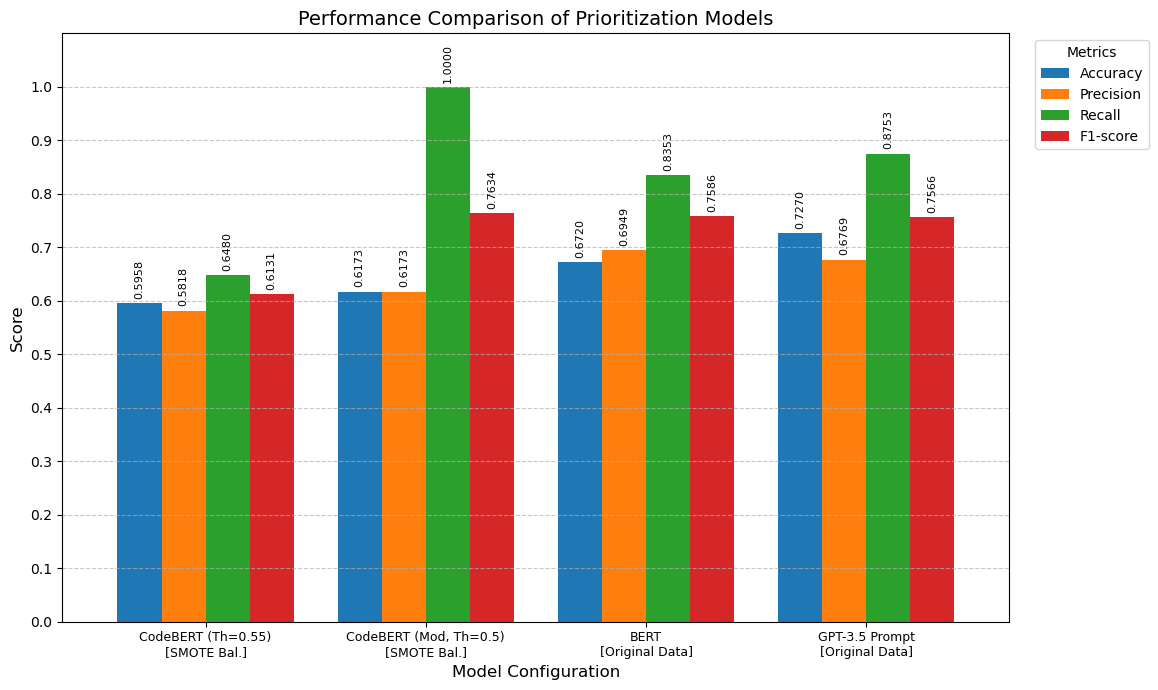

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Data from your results (Table 2) ---
data = {
    'Model': [
        'CodeBERT (Th=0.55)\n[SMOTE Bal.]',
        'CodeBERT (Mod, Th=0.5)\n[SMOTE Bal.]',
        'BERT\n[Original Data]',
        'GPT-3.5 Prompt\n[Original Data]'
    ],
    'Accuracy': [0.5958, 0.6173, 0.6720, 0.7270],
    'Precision': [0.5818, 0.6173, 0.6949, 0.6769],
    'Recall': [0.6480, 1.0000, 0.8353, 0.8753],
    'F1-score': [0.6131, 0.7634, 0.7586, 0.7566]
}

df_results = pd.DataFrame(data)
df_results = df_results.set_index('Model') # Set Model names as index for plotting

# --- Create the plot ---
ax = df_results.plot(kind='bar', figsize=(13, 7), width=0.8, rot=0) # rot=0 keeps x-labels horizontal

# --- Customize the plot ---
plt.title('Performance Comparison of Prioritization Models', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model Configuration', fontsize=12)
plt.ylim(0, 1.10) # Set y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines
plt.xticks(fontsize=9) # Adjust x-tick label size if needed
plt.yticks(np.arange(0, 1.1, 0.1)) # Set y-ticks every 0.1

# Add legend
plt.legend(title='Metrics', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, rotation=90, padding=3)

# Adjust layout to prevent labels overlapping
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust right margin to fit legend

# Save the figure (optional)
plt.savefig('results_comparison_chart.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()
